## LayerTargetLocatorTwoOverlappedRectsTest — nearestX case

Two rects share the same X range. FIRST_RECT is short (height=40), SECOND_RECT is tall (height=300).

When cursor is at y=50 (above FIRST_RECT but inside SECOND_RECT), X-range lookup matches **both** rects.
Expected: tooltips for both. Bug: only SECOND_RECT tooltip appears.


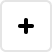
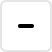
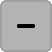
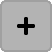
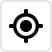
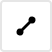
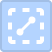
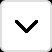
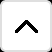
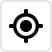
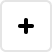
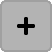
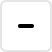
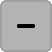
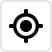
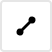
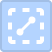
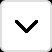
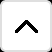
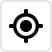

In [1]:
from lets_plot import *
LetsPlot.setup_html()

In [5]:
import pandas as pd

df = pd.DataFrame({
    'xmin': [0, 0],
    'xmax': [20, 20],
    'ymin': [0, 0],
    'ymax': [40, 300],
    'label': ['first (short)', 'second (tall)']
})

# Hover at y≈50 (above the short rect, inside the tall rect).
# Both rects are within x-range [0,20], so nearestX lookup should match both.
# Bug: APPEND_IF_EQUAL drops first rect because its nearest corner (distance≈14)
# loses to second rect (distance=0, cursor is inside it).
(
    ggplot(df)
    + geom_rect(
        aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax', fill='label'),
        alpha=0.4,
        tooltips=layer_tooltips().line('@label')
    )
    + scale_x_continuous(limits=[-5, 60])
    + ggtitle('nearestX: hover above short rect — both tooltips expected')
)